# Data Visualization with Matplotlib

Estimated time needed: **40** minutes

## Objectives

After completing this lab you will be able to:

*   Explore features or characteristics that relate to California housing prices
*   Create **line**, **scatter**, **bar**, and **histogram** plots
*   Combine multiple plots with **subplots**



<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#import_data">Import Data</a></li>
    <li><a href="#line_plot">Line Plot</a></li>
    <li><a href="#scatter_plot">Scatter Plot</a></li>
    <li><a href="#bar_plot">Bar Plot</a></li>
    <li><a href="#hist_plot">Histogram</a></li>
    <li><a href="#subplots">Subplots</a></li>
</ol>

</div>

<hr>


<h3>What are the main characteristics that have the most impact on the house value (<code>gia_nha_trung_vi</code>)?</h3>
<h3>Đặc trưng nào ảnh hưởng mạnh nhất đến giá nhà (<code>gia_nha_trung_vi</code>)?</h3>


<h2 id="import_data">1. Import Data</h2>


<h4>Setup</h4>


Import libraries:


In [1]:
import pandas as pd
import numpy as np


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

c:\Users\pc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\pc\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


In [3]:
import os
os.listdir(path)

['housing.csv']

Load the data and store it in dataframe `df`:


In [4]:
filename = os.path.join(path, 'housing.csv')
filename


'C:\\Users\\pc\\.cache\\kagglehub\\datasets\\camnugent\\california-housing-prices\\versions\\1\\housing.csv'

In [5]:
df = pd.read_csv(filename)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<p>Để dễ theo dõi, đổi tên cột sang tiếng Việt rồi xem lại <code>df.head()</code>.</p>
<p>Rename columns to Vietnamese, then display the first rows again.</p>


In [6]:
df = df.rename(columns={
    "longitude": "kinh_do",
    "latitude": "vi_do",
    "housing_median_age": "tuoi_nha",
    "total_rooms": "tong_phong",
    "total_bedrooms": "tong_phong_ngu",
    "population": "dan_so",
    "households": "so_ho",
    "median_income": "thu_nhap_trung_vi",
    "median_house_value": "gia_nha_trung_vi",
    "ocean_proximity": "vi_tri_bien",
})
df.head()


,kinh_do,vi_do,tuoi_nha,tong_phong,tong_phong_ngu,dan_so,so_ho,thu_nhap_trung_vi,gia_nha_trung_vi,vi_tri_bien
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<p><b>Từ điển cột sau khi đổi tên</b> (tên cũ → tên mới):</p>
<ul>
    <li><code>longitude</code> → <code>kinh_do</code>: kinh độ. Càng về phía tây (Pacific) thì số càng âm (khoảng −124 → −114).</li>
    <li><code>latitude</code> → <code>vi_do</code>: vĩ độ. Càng ra bắc thì số càng lớn (khoảng 32 → 42). Cặp kinh độ + vĩ độ = vị trí khối census trên bản đồ California.</li>
    <li><code>housing_median_age</code> → <code>tuoi_nha</code>: tuổi trung vị của nhà trong khối (năm). Không phải tuổi từng căn, mà mức giữa của khu.</li>
    <li><code>total_rooms</code> → <code>tong_phong</code>: tổng số phòng trong khối.</li>
    <li><code>total_bedrooms</code> → <code>tong_phong_ngu</code>: tổng số phòng ngủ. Cột này có thể có giá trị thiếu (NaN).</li>
    <li><code>population</code> → <code>dan_so</code>: dân số của khối.</li>
    <li><code>households</code> → <code>so_ho</code>: số hộ gia đình.</li>
    <li><code>median_income</code> → <code>thu_nhap_trung_vi</code>: thu nhập trung vị. Trong dataset California Housing, đơn vị là <b>10.000 USD</b> (ví dụ 8.3252 ≈ 83.252 USD/năm).</li>
    <li><code>median_house_value</code> → <code>gia_nha_trung_vi</code>: giá nhà trung vị (USD) — <b>biến đích (target)</b>. Nhiều giá trị bị cắt trần khoảng 500.001.</li>
    <li><code>ocean_proximity</code> → <code>vi_tri_bien</code>: vị trí so với biển (biến phân loại).</li>
</ul>
<p><b>Giá trị của <code>vi_tri_bien</code>:</b></p>
<ul>
    <li><code>&lt;1H OCEAN</code>: cách biển dưới 1 giờ đi lại — nhiều khối nhất.</li>
    <li><code>INLAND</code>: nội địa, xa biển — thường giá nhà thấp hơn.</li>
    <li><code>NEAR OCEAN</code>: sát bờ đại dương.</li>
    <li><code>NEAR BAY</code>: gần vịnh (San Francisco Bay) — thường giá cao.</li>
    <li><code>ISLAND</code>: đảo — rất ít dòng, khó kết luận.</li>
</ul>
<p>Dataset <b>không có tên thành phố</b>. So sánh “lớn / nhỏ” theo <code>vi_tri_bien</code>.</p>


<h2 id="pattern_visualization">2. Analyzing Individual Feature Patterns Using Visualization</h2>


Import visualization packages "Matplotlib" and "Seaborn". Don't forget about "%matplotlib inline" to plot in a Jupyter notebook.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


<h4>How to choose the right visualization method?</h4>
<p>When visualizing individual variables, it is important to first understand what type of variable you are dealing with. This will help us find the right visualization method for that variable.</p>
<p>Khi vẽ từng biến, hãy xác định kiểu dữ liệu trước để chọn đúng biểu đồ.</p>


In [8]:
# list the data types for each column
df.dtypes


kinh_do              float64
vi_do                float64
tuoi_nha             float64
tong_phong           float64
tong_phong_ngu       float64
dan_so               float64
so_ho                float64
thu_nhap_trung_vi    float64
gia_nha_trung_vi     float64
vi_tri_bien              str
dtype: object

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #1:</h3>

<b>What is the data type of the column <code>vi_tri_bien</code>?</b><br/>
Kiểu dữ liệu của cột <code>vi_tri_bien</code> là gì?

</div>


In [9]:
# Write your code below 
df['vi_tri_bien'].dtype

<StringDtype(storage='python', na_value=nan)>

The default setting of "describe" skips variables of type object. We can apply the method "describe" on the variables of type 'object' as follows:


In [10]:
# Write your code below 
display(df.describe())
df.describe(include=['object'])

,kinh_do,vi_do,tuoi_nha,tong_phong,tong_phong_ngu,dan_so,so_ho,thu_nhap_trung_vi,gia_nha_trung_vi
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


C:\Users\pc\AppData\Local\Temp\ipykernel_10792\2472635644.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,vi_tri_bien
count,20640
unique,5
top,<1H OCEAN
freq,9136


<h2 id="line_plot">3. Line Plot</h2>


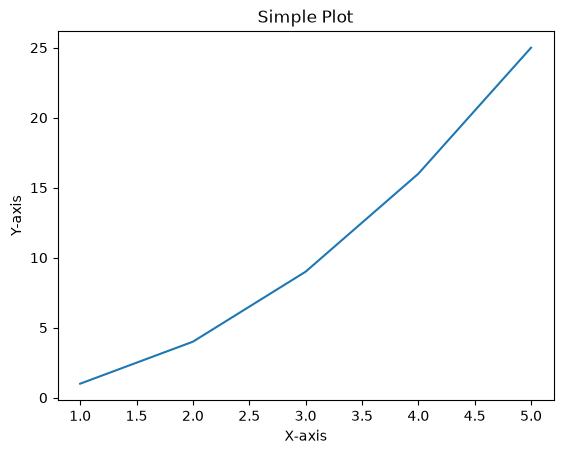

In [11]:
# example
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
plt.plot(x, y)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Simple Plot")
plt.show()


<p>Housing is not a time series, but <code>tuoi_nha</code> still has an order. If we group by age and take the mean house value, we can draw a line.</p>
<p>Dataset housing không phải chuỗi thời gian, nhưng <code>tuoi_nha</code> vẫn có thứ tự. Gom nhóm theo tuổi nhà rồi lấy giá trung bình, ta có thể vẽ line.</p>


Let's plot the mean of "gia_nha_trung_vi" against "tuoi_nha".


In [12]:
# step 1: group by tuoi_nha and calculate the mean of gia_nha_trung_vi
by_age = df.groupby('tuoi_nha')['gia_nha_trung_vi'].mean()



C:\Users\pc\AppData\Local\Temp\ipykernel_10792\1383892973.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


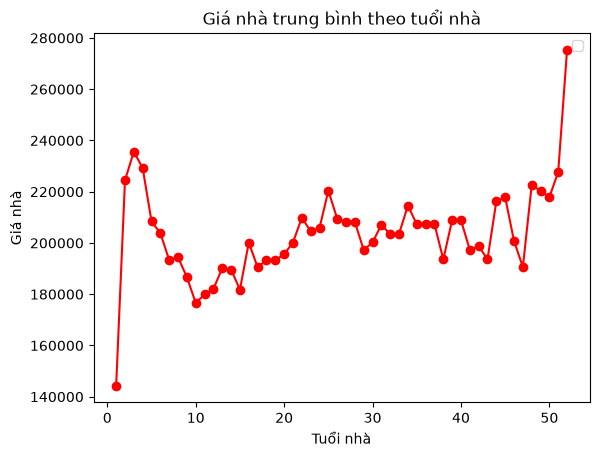

In [13]:
# step 2: plot the mean of gia_nha_trung_vi against tuoi_nha
plt.plot(by_age.index, by_age.values, color="r", linestyle="-", marker='o')
plt.xlabel('Tuổi nhà')
plt.ylabel('Giá nhà')
plt.title('Giá nhà trung bình theo tuổi nhà')
plt.legend()
plt.show()

<p><b>Nhận xét từ hình vẽ / Look at the plot and answer:</b></p>
<ul>
    <li>Khi tuổi nhà tăng, giá trung bình thế nào?<br/>As housing age increases, what happens to the mean house value?</li>
    <li>Có xu hướng tăng ra sao? Đường có thẳng đều không?<br/>How does it trend? Is it a simple straight line?</li>
    <li>Tuổi nhà có liên quan đến giá không? Có phải predictor tuyến tính hoàn hảo không?<br/>Is housing age related to price? Is it a perfect linear predictor?</li>
</ul>


In [14]:
# Write your conclusion
# -Khi tuổi nhà tăng thì giá nhà trung bình có xu hướng tăng.

# -Xu hướng tăng của giá nhà theo tuổi nhà không phải tuyến tính mà có độ giao động lên xuống. 
# Giá nhà tăng mạnh từ 3 năm đầu sau đó giảm sâu đến năm 10 tuổi. Từ lúc 10 tuổi đến 50 tuổi giá nhà giao động lên xuống liên tục cho đến từ 50 tuổi trở đi giá nhà tăng mạnh.

# -Tuổi nhà có liên quan đến giá nhà nhưng không phải là predictor tuyến tính hoàn hảo vì biểu đồ có nhiều điểm gãy khúc và biến động.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #2:</h3>

<p>On the same axes, plot two lines: the mean of <code>gia_nha_trung_vi</code> vs <code>tuoi_nha</code> for <code>INLAND</code> and for <code>NEAR BAY</code>.</p>
<p>Cùng một axes, vẽ hai đường: giá nhà trung bình theo tuổi nhà, một đường <code>INLAND</code>, một đường <code>NEAR BAY</code>.</p>
<p>Hint: if you would like to filter rows, use the following syntax: <code>df[df['vi_tri_bien'] == 'INLAND']</code>. Then use <code>groupby</code> and <code>plt.plot</code> twice, and call <code>plt.legend()</code>.</p>
</div>


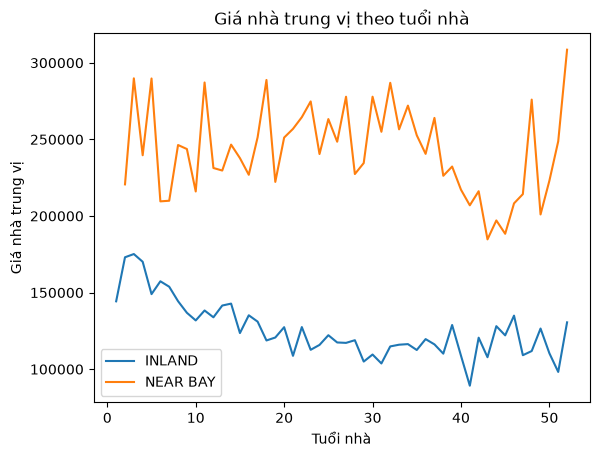

In [15]:
# Write your code below
# step 1: filter INLAND and NEAR BAY
inland = df[df["vi_tri_bien"] == "INLAND"]
near_bay = df[df['vi_tri_bien'] == 'NEAR BAY']

# step 2: group by tuoi_nha, mean of gia_nha_trung_vi
g1 = inland.groupby("tuoi_nha")["gia_nha_trung_vi"].mean()
g2 = near_bay.groupby("tuoi_nha")["gia_nha_trung_vi"].mean()

# step 3: plot two lines on the same axes
plt.plot(g1.index, g1.values, label="INLAND")
plt.plot(g2.index, g2.values, label="NEAR BAY")
plt.xlabel("Tuổi nhà")
plt.ylabel("Giá nhà trung vị")
plt.title("Giá nhà trung vị theo tuổi nhà")
plt.legend()
plt.show()
 

In [16]:
# Write your conclusion
# Gợi ý nhận xét / Hint — nhìn 2 đường rồi trả lời:
# - Đường nào cao hơn? Khu nào (INLAND hay NEAR BAY) có giá nhà trung bình đắt hơn?
# - Khoảng cách giữa 2 đường có giữ xuyên suốt các mức tuổi nhà không?
# - Có đoạn tuổi nào hai đường gần nhau hoặc cắt nhau không?

# -Đường NEAR BAY nằm cao hơn hẳn so với đường INLAND 
#   -> Giá nhà của NEAR BAY cao hơn vượt trội so với giá nhà INLAND.
# -Khoảng cách chênh lệch giữa hai đường duy trì xuyên suốt các mức tuổi nhà.
# -Không có đoạn nào hai đường cắt nhau hoặc tiến lại gần nhau.



<h2 id="scatter_plot">4. Scatter Plot</h2>


<h2>Continuous Numerical Variables:</h2>

<p>Continuous numerical variables are variables that may contain any value within some range. They can be of type "int64" or "float64". A great way to visualize these variables is by using scatterplots.</p>

<p>Biến số liên tục có thể nhận mọi giá trị trong một khoảng. Cách trực quan phổ biến là scatter plot.</p>


Let's see several examples of different relationships:


<h3>Geographic relationship</h3>


Let's find the scatterplot of "kinh_do" and "vi_do".


<p>When extracting two columns, unpack the Series, not the DataFrame. Iterating a DataFrame yields <b>column names</b> (strings), so this mistake plots only <b>one point</b>:</p>
<pre>lat, lon = df[['vi_do', 'kinh_do']]   # WRONG — lat becomes the string "vi_do"</pre>
<p>Khi unpack DataFrame, pandas lấy <b>tên cột</b> (chuỗi), nên scatter chỉ ra 1 điểm — không phải do marker quá nhỏ.</p>


Text(0, 0.5, 'Vĩ độ')

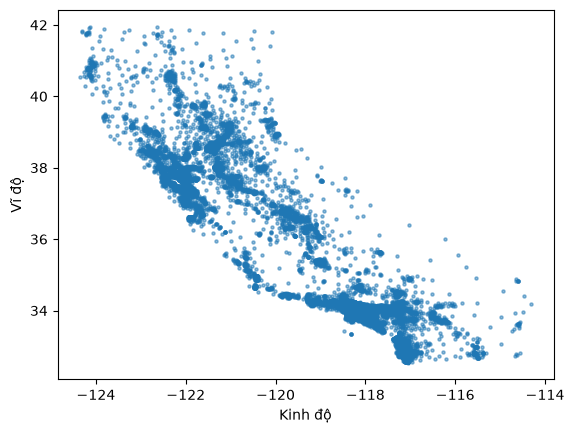

In [17]:
# Write your code below
# step 1: extract lat, lon 
lat = df["vi_do"]
lon = df['kinh_do']

# step 2: scatter (x = kinh_do, y = vi_do)
plt.scatter(lon, lat, s=5, alpha=0.5)
plt.xlabel('Kinh độ')
plt.ylabel('Vĩ độ')


In [18]:
# Write your conclusion
# - Marker nhỏ / alpha để làm gì?

# Marker nhỏ và alpha dùng để giảm các điểm đè lên nhau, giúp ta dễ dàng phân biệt được mật độ phân bố dữ liệu. 
# Vùng nào càng đậm thì mật độ phân bố càng đông, vùng càng mờ thị mật độ phân bố càng ít

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #3:</h3>

<p>Using the same map, encode <b>color</b> by <code>np.log10(dan_so)</code> and <b>size</b> by <code>tong_phong</code>. Add a colorbar.</p>
<p>Cùng bản đồ, mã hóa <b>màu</b> theo log dân số và <b>kích thước</b> theo tổng số phòng. Thêm colorbar.</p>
<p>Hint: <code>plt.scatter(lon, lat, c=np.log10(df['dan_so']), s=df['tong_phong']/50, cmap='viridis', alpha=0.4, linewidth=0)</code> then <code>plt.colorbar(label='...')</code>.</p>
</div>


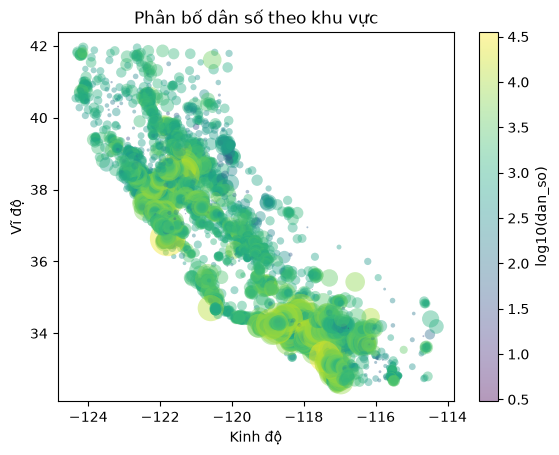

In [19]:

# Write your code below 
plt.scatter(
    lon,
    lat,
    alpha=0.4,
    c=np.log10(df["dan_so"]),
    cmap="viridis",
    s=df["tong_phong"] / 50,
    linewidth=0,
)
plt.colorbar(label="log10(dan_so)")
plt.xlabel("Kinh độ")
plt.ylabel("Vĩ độ")
plt.title("Phân bố dân số theo khu vực")
plt.axis("equal")
plt.show()

<h3>Positive Linear Relationship</h3>


<h4>Theory: Correlation / Tương quan (<code>corr</code>)</h4>
<p>Hệ số tương quan Pearson đo <b>mức độ quan hệ tuyến tính</b> giữa hai biến số. Kết quả nằm trong khoảng <b>[-1, 1]</b>.</p>
<ul>
    <li><b>corr &gt; 0</b> (positive): x tăng thì y có xu hướng <b>tăng</b> — đúng với tiêu đề <i>Positive Linear Relationship</i>.</li>
    <li><b>corr &lt; 0</b> (negative): x tăng thì y có xu hướng <b>giảm</b>.</li>
    <li><b>corr ≈ 0</b>: gần như <b>không</b> có quan hệ tuyến tính (điểm rải, đường gần nằm ngang).</li>
    <li><b>|corr| càng gần 1</b> thì quan hệ tuyến tính càng mạnh; càng gần 0 thì càng yếu.</li>
    <li>Gợi ý đọc nhanh: |corr| &lt; 0.3 yếu; khoảng 0.3–0.7 vừa; &gt; 0.7 mạnh. (Không phải quy tắc tuyệt đối.)</li>
</ul>
<p>Đường chéo của ma trận <code>corr()</code> luôn bằng <b>1</b> (một biến tự tương quan với chính nó). <b>Tương quan không phải nhân quả</b> (correlation ≠ causation).</p>

<p><b>Nhận xét từ hình vẽ / Look at the scatter and answer:</b></p>
<ul>
    <li>Khi <code>thu_nhap_trung_vi</code> tăng, <code>gia_nha_trung_vi</code> đi theo hướng nào? (tăng / giảm / không rõ)</li>
    <li>Các điểm bám sát một đường thẳng hay phân tán? Đây có phải predictor tuyến tính hoàn hảo không?</li>
    <li>Có dải ngang / trần giá bất thường gần 500.000 không?</li>
    <li>Theo lý thuyết trên, bạn kỳ vọng <code>corr</code> dương hay âm? Gần 0 hay gần 1?</li>
</ul>


<p>Tính hệ số tương quan Pearson giữa <code>thu_nhap_trung_vi</code> và <code>gia_nha_trung_vi</code> bằng <code>corr()</code>.</p>
<p>We can examine the correlation between <code>thu_nhap_trung_vi</code> and <code>gia_nha_trung_vi</code>.</p>
<p><b>Hint:</b> chọn đúng 2 cột rồi gọi <code>.corr()</code> — ví dụ cú pháp: <code>df[['cot_x', 'cot_y']].corr()</code>. Ô giao giữa hai biến (không nằm trên đường chéo) mới là hệ số cần đọc.</p>


,gia_nha_trung_vi,thu_nhap_trung_vi
gia_nha_trung_vi,1.000000,0.688075
thu_nhap_trung_vi,0.688075,1.000000


Text(0.5, 0, 'Thu nhập trung vị')

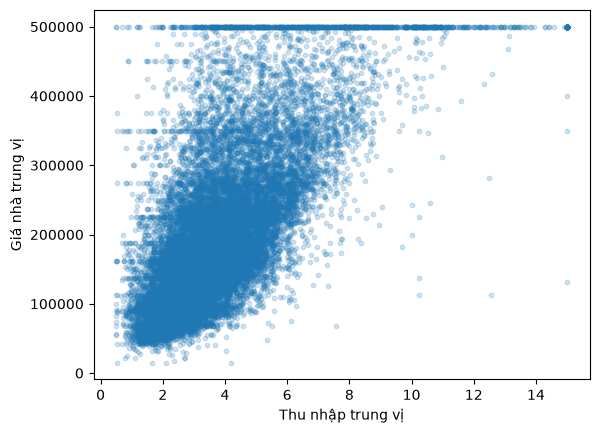

In [20]:
# Write your code below 
display(df[['gia_nha_trung_vi', 'thu_nhap_trung_vi']].corr())
plt.scatter(df['thu_nhap_trung_vi'], df['gia_nha_trung_vi'], alpha=0.2, s=10)
plt.ylabel('Giá nhà trung vị')
plt.xlabel('Thu nhập trung vị')



In [21]:
# Write your conclusion
#  nhìn scatter + bảng corr:
# - corr dương hay âm? gần 0 hay gần 1?
# - Có khớp với hướng các điểm trên scatter không?
# - Vì sao không phải 1.0? (điểm phân tán? trần giá?)

# -Tương quan giữ giá nhà trung vị và thu nhập trung vị corr=0.68 là mối tương quan dương mạnh.
# -> Thu nhập trung vị càng cao thì giá nhà càng cao.

# -Có khớp với hướng các điểm trên scatter vì các điểm trên biểu đồ có xu hướng đi chéo lên trên từ trái sang phải.

# -Các điểm không nằm hoàn hảo trên một đường thẳng duy nhất mà rải rộng một khoảng nhất định.
#     Vì giá nhà không chỉ phụ thuộc vào thu nhập mà còn phụ thuộc vào nhiều yếu tố khác.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #4:</h3>

<p>Using the OO API (<code>fig, ax = plt.subplots()</code>), scatter <code>thu_nhap_trung_vi</code> (x) vs <code>gia_nha_trung_vi</code> (y). Color the points by <code>tuoi_nha</code> and add a colorbar.</p>
<p>Dùng OO API, vẽ scatter thu nhập (x) theo giá nhà (y). Tô màu theo tuổi nhà và thêm colorbar.</p>
<p>Hint: <code>img = ax.scatter(..., c=df['tuoi_nha'], cmap='viridis')</code> then <code>fig.colorbar(img, ax=ax)</code>.</p>
</div>


Text(0, 0.5, 'Giá nhà trung vị')

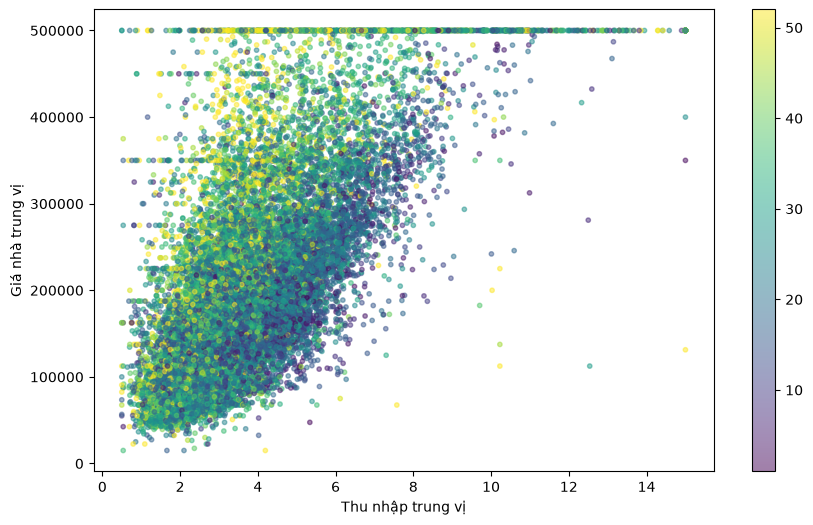

In [22]:
# Write your code below and press Shift+Enter to execute 
fig, ax = plt.subplots(figsize=(10, 6))

img = ax.scatter(df['thu_nhap_trung_vi'], df['gia_nha_trung_vi'], c=df['tuoi_nha'], cmap='viridis', alpha=0.5, s=10)

cbar = fig.colorbar(img, ax = ax)

ax.set_xlabel('Thu nhập trung vị')
ax.set_ylabel('Giá nhà trung vị')

In [23]:
# Write your conclusion
# Có sự tương quan giữ thu nhập trung vị và giá nhà trung vị. Thu nhập trung vị càng cao thì giá nhà trung vị càng cao.
# Các màu sắc trộn lẫn và phân bố rải rác khắp biểu đồ -> không có sự phân tách ranh rới rõ ràng nào giữa các màu.
# Xuất hiện đường thẳng nằm ngang dày đặc ở đỉnh biểu đồ -> dữ liệu bị cắt trần ở mức giá 50000$, có lẽ các mốc giá cao hơn bị gán xuống 500000$

<h2 id="bar_plot">5. Bar Plot</h2>


<h3>Categorical Variables</h3>

<p>These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using bar plots (counts or group means).</p>

<p>Biến phân loại mô tả một đặc trưng, lấy từ một nhóm nhỏ các hạng mục. Cách trực quan phổ biến là bar (đếm) hoặc bar theo trung bình nhóm.</p>


<h3>Value Counts</h3>


<p>Value counts is a good way of understanding how many units of each characteristic/variable we have. We can apply the "value_counts" method on the column "vi_tri_bien". Don’t forget the method "value_counts" only works on pandas series, not pandas dataframes. As a result, we only include one bracket <code>df['vi_tri_bien']</code>, not two brackets <code>df[['vi_tri_bien']]</code>.</p>


In [24]:
df["vi_tri_bien"].value_counts()


vi_tri_bien
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Let's look at the relationship between "vi_tri_bien" and the number of census blocks. From <code>introduction_to_matplotlib.ipynb</code> you used <code>ax.bar(keys, values)</code>.


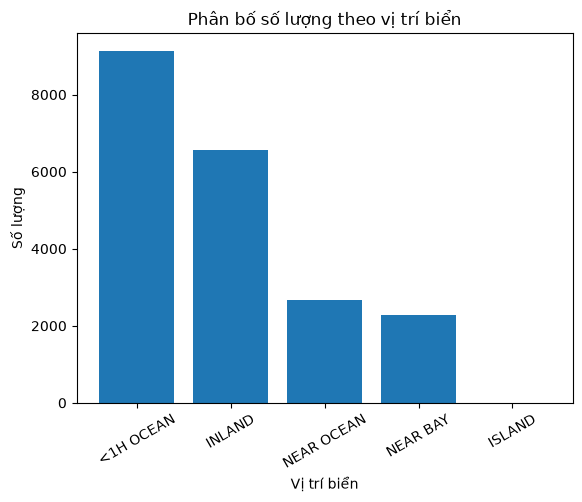

In [25]:
counts = df["vi_tri_bien"].value_counts()

fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set(title='Phân bố số lượng theo vị trí biển', xlabel='Vị trí biển', ylabel='Số lượng')
plt.xticks(rotation=30)
plt.show()


<p>Most districts are <code>&lt;1H OCEAN</code> or <code>INLAND</code>. <code>ISLAND</code> has very few rows, so conclusions about that category will be weak.</p>
<p>Phần lớn các khối thuộc <code>&lt;1H OCEAN</code> hoặc <code>INLAND</code>. <code>ISLAND</code> rất ít dòng nên khó rút kết luận cho nhóm này.</p>


<p>If we want to know, on average, which ocean-proximity category is most valuable, we can group "vi_tri_bien" and then average "gia_nha_trung_vi".</p>


In [26]:
df_group_one = df[["vi_tri_bien", "gia_nha_trung_vi"]]
df_group_one = df_group_one.groupby(["vi_tri_bien"], as_index=False).mean()
df_group_one


,vi_tri_bien,gia_nha_trung_vi
0,<1H OCEAN,240084.285464
1,INLAND,124805.392001
2,ISLAND,380440.000000
3,NEAR BAY,259212.311790
4,NEAR OCEAN,249433.977427


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #5:</h3>

<p>Draw a <b>horizontal</b> bar chart of the mean <code>gia_nha_trung_vi</code> for each <code>vi_tri_bien</code>.</p>
<p>Vẽ bar <b>ngang</b> (<code>barh</code>) giá nhà trung bình theo từng <code>vi_tri_bien</code>.</p>
<p>Hint: use the grouped result above, or <code>df.groupby('vi_tri_bien')['gia_nha_trung_vi'].mean()</code>, then <code>ax.barh(index, values)</code> as in the intro notebook.</p>
</div>


[Text(0.5, 1.0, 'Giá nhà trung bình theo vị trí biển'),
 Text(0.5, 0, 'Giá nhà trung bình'),
 Text(0, 0.5, 'Vị trí biển')]

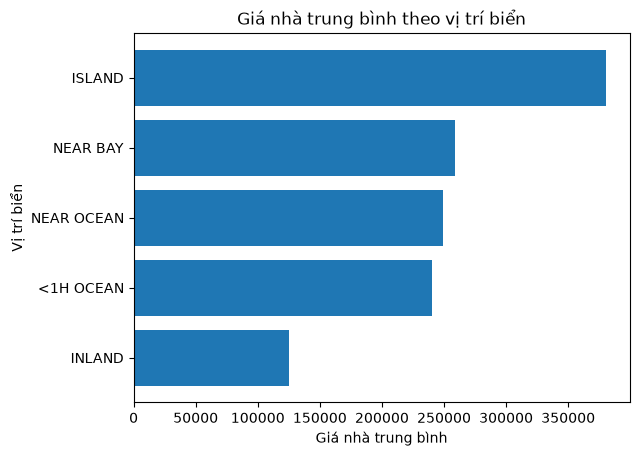

In [27]:
# Write your code below 
df_mean_price = df.groupby('vi_tri_bien')['gia_nha_trung_vi'].mean()
df_mean_price = df_mean_price.sort_values()

fig, ax = plt.subplots()
ax.barh(df_mean_price.index, df_mean_price.values)

ax.set(title='Giá nhà trung bình theo vị trí biển', xlabel='Giá nhà trung bình', ylabel='Vị trí biển')

In [28]:
# Write your conclusion
#  Hint — nhìn barh giá nhà TB theo vi_tri_bien:
# - Nhóm nào đắt nhất? Nhóm nào rẻ nhất?
# - INLAND so với các nhóm gần biển (NEAR BAY, NEAR OCEAN, <1H OCEAN) thế nào?
# - ISLAND có đáng tin không? (nhớ value_counts: nhóm này có nhiều dòng không?)

# Nhóm ISLAND có giá nhà trung bình theo vị trí biển đắt nhất, nhóm INLAND có giá nhà trung bình theo vị trí biển rẻ nhất.
# INLAND có giá trung bình thấp hơn rất nhiều so với các khu vực khác, chỉ bằng một nửa so với các khu vực gần biển và chỉ bằng khoảng 1/3 so với khu vực ISLAND.
# ISLAND không đáng tin cậy về mặt thống kê vì nó chỉ có 5 dòng dữ liệu trên tổng số hơn 20000 dòng.


<h2 id="hist_plot">6. Histogram</h2>


<p>A histogram shows the <b>frequency</b> of a continuous variable. You do not need to group the data first. From <code>introduction_to_matplotlib.ipynb</code>: student heights were drawn from a normal distribution, then plotted with <code>plt.hist</code>.</p>
<p>Histogram mô tả tần suất của một biến liên tục — không cần groupby trước.</p>


Let's find the histogram of "gia_nha_trung_vi".


(array([ 877., 3612., 4099., 3771., 2799., 1769., 1239.,  752.,  479.,
        1243.]),
 array([ 14999. ,  63499.2, 111999.4, 160499.6, 208999.8, 257500. ,
        306000.2, 354500.4, 403000.6, 451500.8, 500001. ]),
 <BarContainer object of 10 artists>)

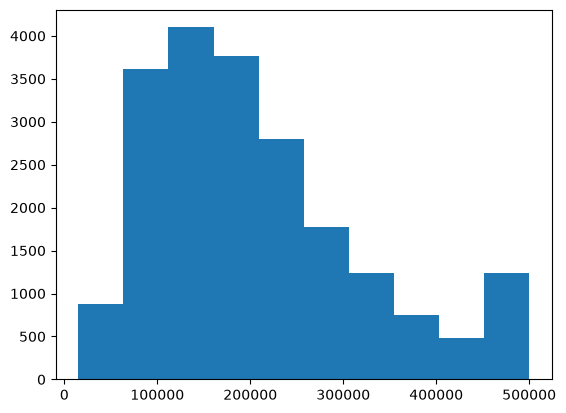

In [29]:
plt.hist(df['gia_nha_trung_vi'])


<p><b>Gợi ý đọc histogram / How to read a histogram:</b></p>
<ul>
    <li><b>Lệch phải (right-skewed)</b>: đuôi dài về bên phải — nhiều giá trị vừa/phải, một số rất lớn.</li>
    <li><b>Lệch trái (left-skewed)</b>: đuôi dài về bên trái.</li>
    <li><b>Đối xứng</b>: hai bên gần giống nhau (gần phân phối chuẩn).</li>
</ul>
<p><b>Nhận xét từ hình vẽ / Look at the plot and answer:</b></p>
<ul>
    <li>Phân phối <code>gia_nha_trung_vi</code> lệch trái, lệch phải, hay khá đối xứng?</li>
    <li>Có cụm / cột bất thường ở đầu phải (gần giá trị lớn nhất ~500.000) không?</li>
    <li>Nếu có, điều đó gợi ý giá nhà bị <b>cắt trần (capped)</b> không? Việc này ảnh hưởng thế nào nếu sau này dự đoán giá nhà?</li>
</ul>


In [30]:
# Write your conclusion
# Gợi ý nhận xét / Hint:
# - Lệch trái / lệch phải / đối xứng?
# - Có cột cao bất thường gần max (~500.000) không?
# - Có phải giá bị cắt trần? Việc này có ảnh hưởng khi predict không?

# Hình trên có đuôi kéo dài về bên phải, đồ thị lệch phải. Phần lớn dữ liệu tập trung ở vùng giá thấp và trung bình (100000$-200000$)
# Có cột cao bất thường nằm ngoài cùng bên phải. Cột cao đột biến khoảng 1200 trong khi đó về cơ bản dồ thị cho giá càng cao thì số lượng càng giảm mà riêng cột này lại có sự nhảy vọt về số lượng.
# Giá của dữ liệu bị cắt trần vì tất các các căn nhà giá cao nhất đều chỉ đến mức giới hạn 500000$ là dừng lại. Việc bị cắt trần này có thể ảnh hưởng tới việc dự đoán và độ chính xác của dữ liệu



Using the OO API we can label the counts on each bar, as in the intro notebook:


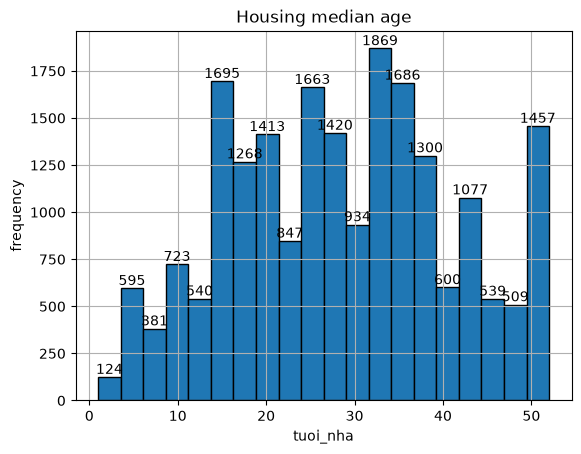

In [31]:
fig, ax = plt.subplots()
n, bins, patches = ax.hist(df["tuoi_nha"], bins=20, edgecolor="black")
ax.set(title="Housing median age", xlabel="tuoi_nha", ylabel="frequency")
ax.bar_label(patches)
ax.grid(True)
plt.show()


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #6:</h3>

<p>Plot a histogram of <code>thu_nhap_trung_vi</code> with <code>bins=30</code> and black edges. Use the OO API and <code>ax.bar_label(patches)</code>.</p>
<p>Vẽ histogram <code>thu_nhap_trung_vi</code>, <code>bins=30</code>, viền đen. Dùng OO API và <code>ax.bar_label(patches)</code>.</p>
<p>Hint: <code>n, bins, patches = ax.hist(df['thu_nhap_trung_vi'], bins=30, edgecolor='black')</code></p>
</div>


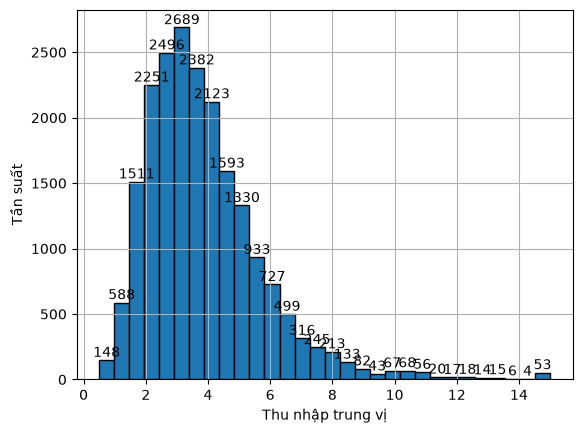

In [32]:
# Write your code below
fig, ax = plt.subplots()
n, bins, patches=  ax.hist(df['thu_nhap_trung_vi'], bins=30, edgecolor='black')
ax.set(xlabel='Thu nhập trung vị', ylabel='Tần suất')
ax.bar_label(patches)
ax.grid(True)

In [33]:
# # Write your conclusion
# Đồ thị có phần đỉnh dồn mạnh về bên trái và có đuôi kéo dài về bên phải -> đồ thị lệch phải.
# Phần lớn người dân có thu nhập trung vị nằm trong khoảng 2-4. Cột đạt tần suẩt cao nhất là 3 với 2.689 khối nhà.


<h2 id="subplots">7. Subplots</h2>


<p>The OO API can split one figure into a grid. From <code>introduction_to_matplotlib.ipynb</code> there are two equivalent options.</p>
<p>OO API cho phép chia một figure thành lưới. Trong bài intro có hai cách tương đương.</p>


<h4>Option 1: unpack each axes</h4>


Let's put a line, a scatter, a bar, and a histogram on a 2×2 grid.


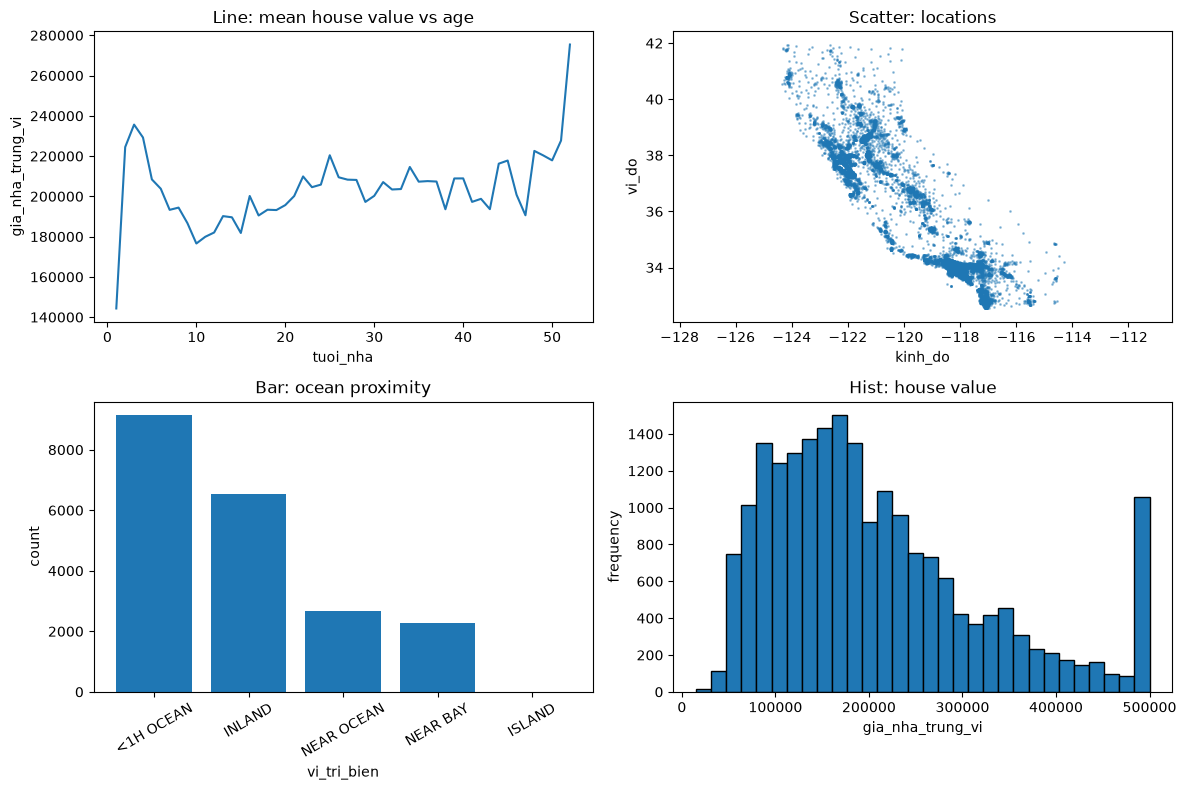

In [34]:
fig, [(ax1, ax2), (ax3, ax4)] = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

ax1.plot(by_age.index, by_age.values)
ax1.set(title="Line: mean house value vs age", xlabel="tuoi_nha", ylabel="gia_nha_trung_vi")

ax2.scatter(lon, lat, s=1, alpha=0.4)
ax2.set(title="Scatter: locations", xlabel="kinh_do", ylabel="vi_do")
ax2.axis("equal")

ax3.bar(counts.index, counts.values)
ax3.set(title="Bar: ocean proximity", xlabel="vi_tri_bien", ylabel="count")
ax3.tick_params(axis="x", rotation=30)

ax4.hist(df["gia_nha_trung_vi"], bins=30, edgecolor="black")
ax4.set(title="Hist: house value", xlabel="gia_nha_trung_vi", ylabel="frequency")

fig.tight_layout()
plt.show()


<p>Each axes is an independent plot: line, scatter, bar, and hist share one figure. <code>fig.tight_layout()</code> keeps titles and labels from overlapping.</p>
<p>Mỗi axes là một biểu đồ độc lập. <code>tight_layout()</code> giúp tiêu đề và nhãn không chồng lên nhau.</p>


<h4>Option 2: index the axes array</h4>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #7:</h3>

<p>Redraw the same 2×2 figure using option 2: <code>fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))</code> and <code>ax[0, 0]</code>, <code>ax[0, 1]</code>, <code>ax[1, 0]</code>, <code>ax[1, 1]</code>.</p>
<p>Vẽ lại lưới 2×2 giống ví dụ trên, nhưng dùng chỉ số <code>ax[row, col]</code>.</p>
<p>Hint: <code>ax[0, 0].plot(...)</code>, <code>ax[0, 1].scatter(...)</code>, <code>ax[1, 0].bar(...)</code>, <code>ax[1, 1].hist(...)</code>, then <code>fig.tight_layout()</code>.</p>
</div>


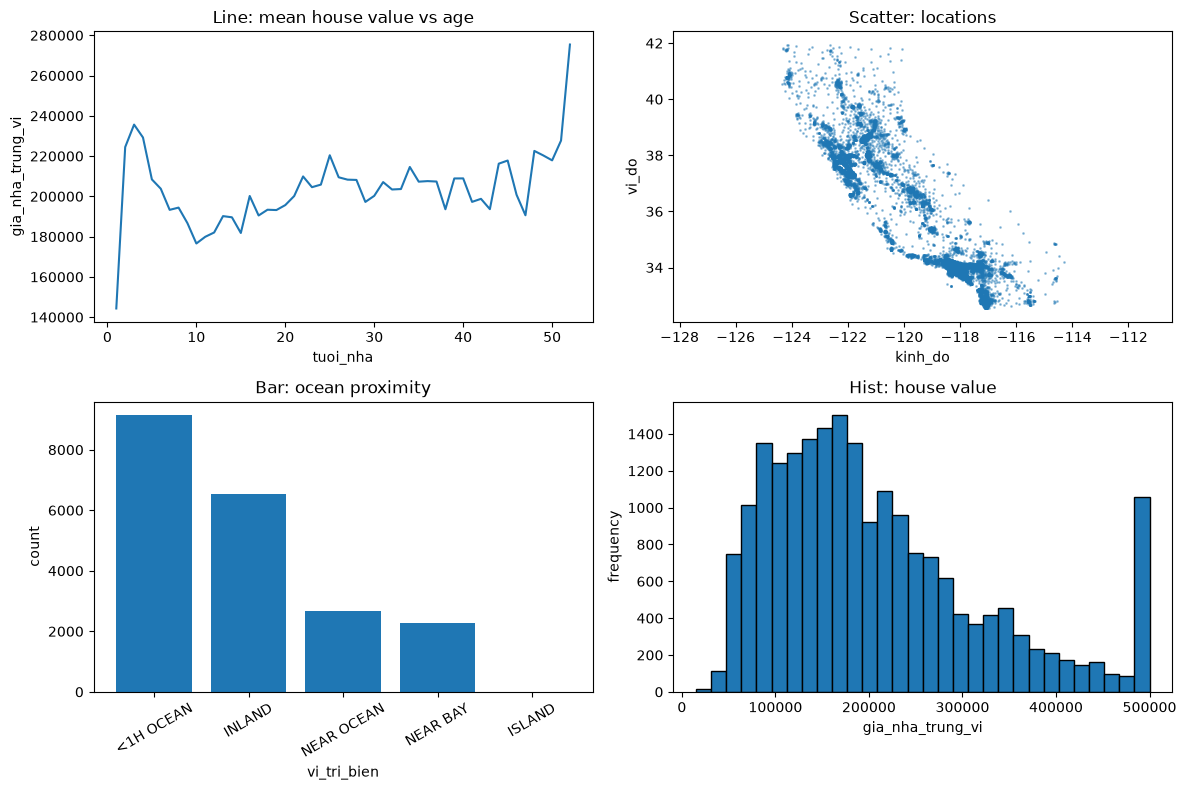

In [36]:
# Write your code below
fig, ax= plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

ax[0, 0].plot(by_age.index, by_age.values)
ax[0, 0].set(title="Line: mean house value vs age", xlabel="tuoi_nha", ylabel="gia_nha_trung_vi")

ax[0, 1].scatter(lon, lat, s=1, alpha=0.4)
ax[0, 1].set(title="Scatter: locations", xlabel="kinh_do", ylabel="vi_do")
ax[0, 1].axis("equal")

ax[1, 0].bar(counts.index, counts.values)
ax[1, 0].set(title="Bar: ocean proximity", xlabel="vi_tri_bien", ylabel="count")
ax[1, 0].tick_params(axis="x", rotation=30)

ax[1, 1].hist(df["gia_nha_trung_vi"], bins=30, edgecolor="black")
ax[1, 1].set(title="Hist: house value", xlabel="gia_nha_trung_vi", ylabel="frequency")

fig.tight_layout()
plt.show()


<h3>Conclusion: Important Variables</h3>


<p>We now have a better idea of what our data looks like and which variables are important to take into account when predicting the house value. From the plots above, we have narrowed it down to the following variables:</p>

Continuous numerical variables:

<ul>
    <li>thu_nhap_trung_vi</li>
    <li>tuoi_nha</li>
    <li>kinh_do / vi_do (location)</li>
    <li>dan_so / tong_phong (size of the district)</li>
</ul>

Categorical variables:

<ul>
    <li>vi_tri_bien</li>
</ul>

<p>As we now move into building machine learning models to automate our analysis, feeding the model with variables that meaningfully affect our target variable will improve our model's prediction performance.</p>
